# Stock Direction Prediction with XGBoost
### CP020003 — Artificial Intelligence · Final Project

**Project topic:** Predicting next-period stock price direction (up / down) from
technical indicators, using XGBoost — connected to our live dashboard, **Stockscope**.

**Model / Task type:** Binary Classification (tabular, time series features)

| Group No. | Group Name | Student Name | Student ID |
|---|---|---|---|
| _fill in_ | _fill in_ | _member 1_ | _id_ |
| | | _member 2_ | _id_ |
| | | _member 3_ | _id_ |
| | | _member 4_ | _id_ |
| | | _member 5_ | _id_ |


## 1. Motivation

Our team built **Stockscope**, a real-time stock dashboard (Streamlit + yfinance) that already
computes technical indicators (RSI, MACD, moving averages, support/resistance zones) for any
ticker. A natural next question: **can those same indicators predict where the price goes next?**

We frame this as a **supervised binary classification** problem — *will the closing price be
higher N trading days from now?* — and train **XGBoost** to answer it, because:

- Our features are tabular (indicator values), not images or free text → tree ensembles are a
  strong, standard fit.
- XGBoost trains fast even on a laptop / free Colab CPU, so we can iterate and validate carefully.
- Feature importance and SHAP help describe how the fitted model uses inputs. These are
  descriptive results, not causal explanations of price moves.

We treat this explicitly as a controlled experiment in market efficiency, **not** as investment
advice — see the Limitations section at the end. Because financial time series are noisy, **how
carefully the experiment is run matters more than the headline number**: the main goal of this
notebook is a leakage-free pipeline and an honest statistical read of the result.


## 2. Setup

In [19]:
# If running in Google Colab, uncomment the line below first:
# !pip install -q xgboost scikit-learn shap yfinance

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 3. Data Collection

We pull **5 years of daily OHLCV data** for 20 large-cap US tickers spanning multiple sectors
(tech, finance, energy, healthcare, consumer, media) directly from Yahoo Finance via `yfinance` —
the same data source our Stockscope dashboard already uses live. Using multiple sectors, rather
than a single stock, gives the model more rows and reduces the risk of learning one company's
idiosyncratic quirks instead of general technical-indicator behavior.


In [20]:
TICKERS = [
    "AAPL", "MSFT", "NVDA", "JPM", "XOM", "JNJ", "AMZN", "KO", "GOOGL", "META",
    "WMT", "PG", "V", "MA", "DIS", "NFLX", "AMD", "INTC", "BAC", "CVX",
]
START_DATE = "2021-10-04"
END_DATE_EXCLUSIVE = "2026-10-02"  # Fixed snapshot, for reproducible slides.
yf.set_tz_cache_location(str(Path.cwd() / ".yfinance_cache"))

raw = yf.download(
    TICKERS, start=START_DATE, end=END_DATE_EXCLUSIVE, interval="1d",
    auto_adjust=False, progress=False, group_by="ticker", threads=False,
)
if raw.empty:
    raise RuntimeError("Yahoo Finance returned no rows. Check the connection/data source.")

frames = []
for t in TICKERS:
    if t not in raw.columns.get_level_values(0):
        raise RuntimeError(f"No downloaded data for {t}; do not silently change the sample.")
    df = raw[t].copy().dropna(subset=["Close"])
    if df.empty:
        raise RuntimeError(f"No usable Close prices for {t}.")
    df["Ticker"] = t
    frames.append(df)

full = pd.concat(frames).reset_index()
print(f"Rows: {len(full):,} | Tickers: {full['Ticker'].nunique()} | "
      f"Date range: {full['Date'].min().date()} -> {full['Date'].max().date()}")
full.head()


Rows: 25,080 | Tickers: 20 | Date range: 2021-10-04 -> 2026-10-01


Price,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2021-10-04,141.759995,142.210007,138.270004,139.139999,135.713135,98322000,AAPL
1,2021-10-05,139.490005,142.240005,139.360001,141.110001,137.634644,80861100,AAPL
2,2021-10-06,139.470001,142.149994,138.369995,142.000000,138.502670,83221100,AAPL
3,2021-10-07,143.059998,144.220001,142.720001,143.289993,139.760910,61732700,AAPL
4,2021-10-08,144.029999,144.179993,142.559998,142.899994,139.380524,58773200,AAPL


## 4. Dataset Understanding (EDA)

Before modeling, we look at what the raw data actually contains: how many rows per ticker,
whether any values are missing, and what the price series looks like.


In [21]:
print("Rows per ticker:")
print(full.groupby("Ticker").size())

print("\nMissing values per column:")
print(full[["Open", "High", "Low", "Close", "Volume"]].isna().sum())

full[["Open", "High", "Low", "Close", "Volume"]].describe()


Rows per ticker:
Ticker
AAPL     1254
AMD      1254
AMZN     1254
BAC      1254
CVX      1254
DIS      1254
GOOGL    1254
INTC     1254
JNJ      1254
JPM      1254
KO       1254
MA       1254
META     1254
MSFT     1254
NFLX     1254
NVDA     1254
PG       1254
V        1254
WMT      1254
XOM      1254
dtype: int64

Missing values per column:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


Price,Open,High,Low,Close,Volume
count,25080.000000,25080.000000,25080.000000,25080.000000,2.508000e+04
mean,177.520106,179.513581,175.537874,177.574919,4.524506e+07
std,137.416580,138.902674,135.899059,137.436009,9.094447e+07
min,10.971000,11.735000,10.813000,11.227000,9.444000e+05
25%,85.137499,86.379997,83.699249,85.114998,9.016275e+06
50%,146.955002,148.500000,145.460007,146.898254,1.977780e+07
75%,222.000000,224.422497,219.395004,221.927498,4.228425e+07
max,791.150024,796.250000,780.820007,790.000000,1.543911e+09


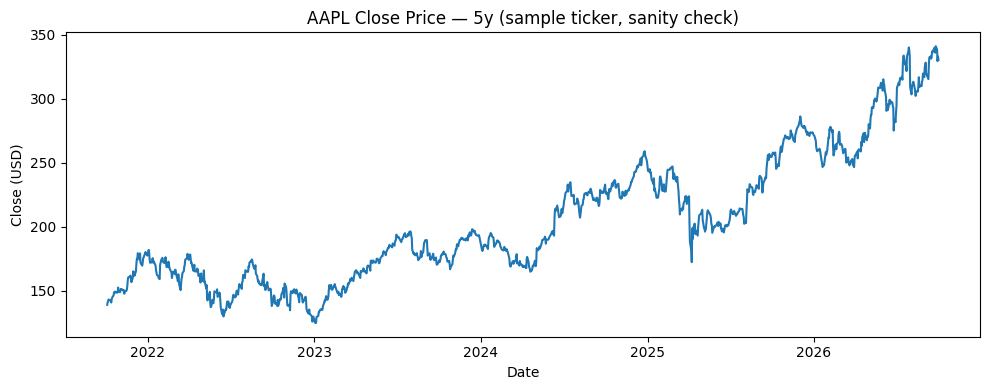

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
sample = full[full["Ticker"] == "AAPL"]
ax.plot(sample["Date"], sample["Close"])
ax.set_title("AAPL Close Price — 5y (sample ticker, sanity check)")
ax.set_xlabel("Date"); ax.set_ylabel("Close (USD)")
plt.tight_layout(); plt.show()


Worst single-day return in the dataset: -35.1%
Best single-day return in the dataset : 24.4%


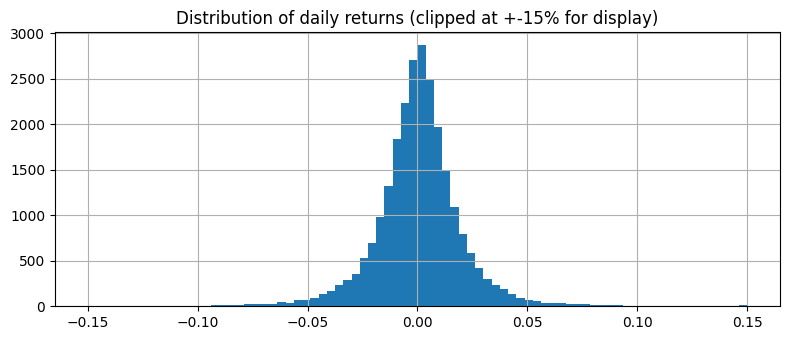

In [23]:
# Sanity check on data quality: the largest single-day drop across all tickers.
# yfinance's 'Close' is already split-adjusted, so a drop near -90% would signal a data problem.
daily_ret = full.sort_values(["Ticker", "Date"]).groupby("Ticker")["Close"].pct_change()
print(f"Worst single-day return in the dataset: {daily_ret.min():.1%}")
print(f"Best single-day return in the dataset : {daily_ret.max():.1%}")

fig, ax = plt.subplots(figsize=(8, 3.5))
daily_ret.dropna().clip(-0.15, 0.15).hist(bins=80, ax=ax)
ax.set_title("Distribution of daily returns (clipped at +-15% for display)")
plt.tight_layout(); plt.show()


## 5. Feature Engineering

We compute the same technical indicators Stockscope shows on the dashboard:

| Feature | Meaning |
|---|---|
| `ret_1d`, `ret_5d`, `ret_10d`, `ret_21d` | Past return over 1/5/10/21 trading days (momentum) |
| `rsi14` | 14-day Relative Strength Index (overbought/oversold) |
| `macd_hist` | MACD histogram (trend strength/direction) |
| `dist_sma20`, `dist_sma50` | % distance of price from its 20/50-day moving average |
| `vol_ratio` | Today's volume vs. its 20-day average (unusual activity) |
| `volatility_20d` | Rolling std-dev of daily returns (risk/choppiness) |

**No look-ahead leakage:** every feature above is computed with `rolling()` / `ewm()` windows
that only look **backward** in time. We compute features **per ticker** so no information ever
crosses from one company's timeline into another's.


In [24]:
def sma(s, w): return s.rolling(w, min_periods=w).mean()
def ema(s, span): return s.ewm(span=span, adjust=False).mean()

def rsi(s, period=14):
    delta = s.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    value = 100 - 100 / (1 + rs)
    value = value.mask((avg_loss == 0) & (avg_gain > 0), 100)
    value = value.mask((avg_loss == 0) & (avg_gain == 0), 50)
    return value.fillna(50)

def macd_hist_line(s, fast=12, slow=26, signal=9):
    macd_line = ema(s, fast) - ema(s, slow)
    signal_line = ema(macd_line, signal)
    return macd_line - signal_line


FEATURES = [
    "ret_1d", "ret_5d", "ret_10d", "ret_21d",
    "rsi14", "macd_hist", "dist_sma20", "dist_sma50",
    "vol_ratio", "volatility_20d",
]

def make_features(g, horizon):
    g = g.sort_values("Date").copy()
    close = g["Close"]
    g["ret_1d"] = close.pct_change(1)
    g["ret_5d"] = close.pct_change(5)
    g["ret_10d"] = close.pct_change(10)
    g["ret_21d"] = close.pct_change(21)
    g["rsi14"] = rsi(close)
    g["macd_hist"] = macd_hist_line(close)
    sma20 = sma(close, 20)
    sma50 = sma(close, 50)
    g["dist_sma20"] = (close - sma20) / sma20
    g["dist_sma50"] = (close - sma50) / sma50
    g["vol_ratio"] = g["Volume"] / g["Volume"].rolling(20, min_periods=20).mean()
    g["volatility_20d"] = g["ret_1d"].rolling(20, min_periods=20).std()
    # Label uses ONLY future price (never fed back as a feature) — see section 6.
    # The last `horizon` rows have no future price, so their label must be NaN (not 0).
    future_close = close.shift(-horizon)
    g["target_date"] = g["Date"].shift(-horizon)
    g["label_up"] = (future_close > close).astype(float).where(future_close.notna())
    return g


def build_feature_frame(df, horizon):
    # Explicit loop (not groupby().apply()) — pandas' groupby-apply column handling
    # changed across versions (2.2 warns, 3.0 drops the grouping column from the
    # result by default), so a plain loop + concat is the version-safe choice here.
    parts = [make_features(df[df["Ticker"] == t], horizon) for t in df["Ticker"].unique()]
    return pd.concat(parts, ignore_index=True)


## 6. Labeling — Next-Period Direction

`label_up = 1` if the close price `horizon` trading days from now is **higher** than today's
close, else `0`. The label is built with `close.shift(-horizon)` — it reaches **forward** in
time — but it is only ever used as the target `y`, never joined back into `X`. The last
`horizon` rows of each ticker have **no** future price yet, so their label is set to `NaN` and
those rows are dropped (a plain `>` comparison would silently turn them into a false "down"
label, so we mask them explicitly).

This separation — features strictly backward-looking, label strictly forward-looking, never mixed
— is what keeps the pipeline **leakage-free**.


## 7. Train / Test Split — Chronological, With a Label Purge

A random 80/20 row split would leak information: rows from the same week end up on both sides,
and because indicators are autocorrelated (today's RSI is close to yesterday's), the model would
partly "memorize" the test period instead of generalizing to the future.

Instead we use a **single global date cutoff** at 80% of the trading calendar. Every training
row happens before every test row, across all 20 tickers at once — mimicking real use: trained
on the past, evaluated on data it has never seen.

**Label purge.** A training row on date `t` has a label taken from its later `target_date`.
We keep that row only when `target_date` is strictly before the test cutoff. This works even
when one ticker has missing trading dates.


In [25]:
HORIZONS = [1, 5, 10]          # trading days ahead

def prepare(h):
    # Features + label for horizon h, sorted chronologically (Date, then Ticker).
    d = build_feature_frame(full, h)
    d = d.dropna(subset=FEATURES + ["label_up"]).copy()
    d["label_up"] = d["label_up"].astype(int)
    return d.sort_values(["Date", "Ticker"]).reset_index(drop=True)

def time_split(d, h, test_frac=0.2):
    dates = np.array(sorted(d["Date"].unique()))
    cut_i = int(len(dates) * (1 - test_frac))
    cutoff = dates[cut_i]
    train = d[(d["Date"] < cutoff) & (d["target_date"] < cutoff)]
    test = d[d["Date"] >= cutoff]
    train_end = train["Date"].max()
    assert train["target_date"].max() < test["Date"].min()
    return train, test, cutoff, train_end

data_h = {h: prepare(h) for h in HORIZONS}
splits = {h: time_split(data_h[h], h) for h in HORIZONS}

rows = []
for h in HORIZONS:
    tr, te, cutoff, train_end = splits[h]
    rows.append({
        "horizon": h, "train_rows": len(tr), "test_rows": len(te),
        "train_end": train_end.date(), "test_start": cutoff.date(),
        "train_up_share": round(tr["label_up"].mean(), 3),
        "test_up_share": round(te["label_up"].mean(), 3),
    })
pd.DataFrame(rows)


,horizon,train_rows,test_rows,train_end,test_start,train_up_share,test_up_share
0,1,19240,4820,2025-10-13,2025-10-15,0.520,0.513
1,5,19100,4800,2025-10-02,2025-10-10,0.543,0.531
2,10,18920,4780,2025-09-19,2025-10-06,0.551,0.527


## 8. Choosing the Horizon and Hyperparameters — Training Data Only

Both the **prediction horizon** (1, 5 or 10 days) and the **XGBoost hyperparameters** are choices
we have to make. If we picked them by looking at test-set results, the test set would no longer
be an honest estimate (that is a form of leakage). So we choose both using **only the training
data**, with chronological cross-validation:

- `TimeSeriesSplit` with 4 expanding-window folds on **unique dates**, so every ticker from
  the same date stays on the same side of the fold;
- in each fold, purge training rows whose `target_date` reaches validation. This checks the
  actual label date for each ticker instead of approximating a gap by number of rows.

The combination with the best mean validation ROC-AUC becomes our main model. The test set is
untouched until section 10.


In [8]:
GRID = [
    {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 200},
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 300},
    {"max_depth": 3, "learning_rate": 0.10, "n_estimators": 150},
]

def cv_auc(train, h, params):
    dates = np.array(sorted(train["Date"].unique()))
    tscv = TimeSeriesSplit(n_splits=4)
    aucs = []
    for date_tr_idx, date_va_idx in tscv.split(dates):
        validation_start = dates[date_va_idx[0]]
        fold_train = train[(train["Date"].isin(dates[date_tr_idx])) &
                           (train["target_date"] < validation_start)]
        fold_val = train[train["Date"].isin(dates[date_va_idx])]
        assert fold_train["target_date"].max() < fold_val["Date"].min()
        m = XGBClassifier(**params, subsample=0.8, colsample_bytree=0.8,
                          eval_metric="logloss", random_state=RANDOM_STATE)
        m.fit(fold_train[FEATURES], fold_train["label_up"])
        aucs.append(roc_auc_score(fold_val["label_up"],
                                  m.predict_proba(fold_val[FEATURES])[:, 1]))
    return float(np.mean(aucs))

cv_rows = []
for h in HORIZONS:
    for params in GRID:
        cv_rows.append({"horizon": h, **params, "cv_auc": round(cv_auc(splits[h][0], h, params), 4)})
cv_df = pd.DataFrame(cv_rows)
cv_df


,horizon,max_depth,learning_rate,n_estimators,cv_auc
0,1,3,0.05,200,0.5070
1,1,4,0.05,300,0.5060
2,1,3,0.10,150,0.5065
3,5,3,0.05,200,0.4952
4,5,4,0.05,300,0.4962
5,5,3,0.10,150,0.4959
6,10,3,0.05,200,0.4766
7,10,4,0.05,300,0.4818
8,10,3,0.10,150,0.4761


In [9]:
# Best hyperparameters per horizon, and the horizon with the best validation AUC overall.
best_by_h = {}
for h in HORIZONS:
    r = cv_df[cv_df["horizon"] == h].sort_values("cv_auc").iloc[-1]
    best_by_h[h] = {
        "max_depth": int(r["max_depth"]),
        "learning_rate": float(r["learning_rate"]),
        "n_estimators": int(r["n_estimators"]),
        "cv_auc": float(r["cv_auc"]),
    }

HORIZON = max(HORIZONS, key=lambda h: best_by_h[h]["cv_auc"])
best_params = {k: v for k, v in best_by_h[HORIZON].items() if k != "cv_auc"}
print("Validation AUC by horizon:", {h: best_by_h[h]["cv_auc"] for h in HORIZONS})
print(f"Selected horizon (training-data CV only): {HORIZON} day(s)")
print("Selected hyperparameters:", best_params)

train, test, cutoff, train_end = splits[HORIZON]
X_train, y_train = train[FEATURES], train["label_up"]
X_test, y_test = test[FEATURES], test["label_up"]
print(f"Train rows: {len(train):,} (up to {train_end.date()}) | Test rows: {len(test):,} (from {cutoff.date()})")


Validation AUC by horizon: {1: 0.507, 5: 0.4962, 10: 0.4818}
Selected horizon (training-data CV only): 1 day(s)
Selected hyperparameters: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200}
Train rows: 19,240 (up to 2025-10-13) | Test rows: 4,820 (from 2025-10-15)


## 9. Model Training — Baselines vs. XGBoost

We compare three models on the *exact same* leakage-free split, so the comparison is fair:

1. **Logistic Regression** — simplest linear baseline (features standardized, scaler fitted on
   the training set only).
2. **Random Forest** — a second tree-ensemble baseline, no boosting.
3. **XGBoost** — our chosen model, with the hyperparameters selected in section 8.


In [10]:
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

xgb_model = XGBClassifier(
    **best_params, subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train)
print("Models trained.")


Models trained.


## 10. Evaluation

Accuracy alone is misleading when classes are nearly balanced, so we report ROC-AUC too and
compare against the **majority-class baseline** (always predict the more common label).

We also attach a **95% confidence interval to the ROC-AUC** using a *block bootstrap over
dates*: we resample blocks of 10 consecutive trading days (keeping all 20 tickers of each day
together) and recompute the AUC. This partly accounts for correlation between nearby dates
and stocks on the same date. An interval containing 0.5 means this test does not establish an
edge over random ranking; it does not prove the true AUC is exactly 0.5.


In [11]:
rng = np.random.default_rng(RANDOM_STATE)

def block_bootstrap_auc(dates, y, p, block=10, n_boot=500):
    # Block bootstrap over trading days: returns (2.5th, 97.5th) percentile of AUC.
    unique_dates = np.array(sorted(pd.unique(dates)))
    idx_by_date = {d: np.where(dates == d)[0] for d in unique_dates}
    n_blocks = int(np.ceil(len(unique_dates) / block))
    aucs = []
    for _ in range(n_boot):
        starts = rng.integers(0, len(unique_dates) - block + 1, size=n_blocks)
        ids = np.concatenate([idx_by_date[d] for s in starts for d in unique_dates[s:s + block]])
        if len(np.unique(y[ids])) < 2:
            continue
        aucs.append(roc_auc_score(y[ids], p[ids]))
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

test_dates = test["Date"].values
y_test_arr = y_test.values

def evaluate(name, proba):
    pred = (proba > 0.5).astype(int)
    lo, hi = block_bootstrap_auc(test_dates, y_test_arr, proba)
    return {
        "model": name,
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "precision": round(precision_score(y_test, pred), 4),
        "recall": round(recall_score(y_test, pred), 4),
        "f1": round(f1_score(y_test, pred), 4),
        "roc_auc": round(roc_auc_score(y_test, proba), 4),
        "auc_95ci": f"{lo:.3f} - {hi:.3f}",
        "ci_low": lo, "ci_high": hi,
    }

proba_lr = logreg.predict_proba(X_test_s)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

baseline_acc = max(y_test.mean(), 1 - y_test.mean())
results = [{"model": "Majority-class baseline", "accuracy": round(baseline_acc, 4),
            "precision": None, "recall": None, "f1": None, "roc_auc": 0.5,
            "auc_95ci": "-", "ci_low": None, "ci_high": None}]
results.append(evaluate("Logistic Regression", proba_lr))
results.append(evaluate("Random Forest", proba_rf))
results.append(evaluate("XGBoost (ours)", proba_xgb))

results_df = pd.DataFrame(results)
results_df.drop(columns=["ci_low", "ci_high"])


,model,accuracy,precision,recall,f1,roc_auc,auc_95ci
0,Majority-class baseline,0.5127,NaN,NaN,NaN,0.5000,-
1,Logistic Regression,0.5160,0.5162,0.8903,0.6535,0.5129,0.487 - 0.537
2,Random Forest,0.5135,0.5159,0.8276,0.6356,0.4999,0.482 - 0.515
3,XGBoost (ours),0.5060,0.5127,0.7365,0.6046,0.5005,0.485 - 0.516


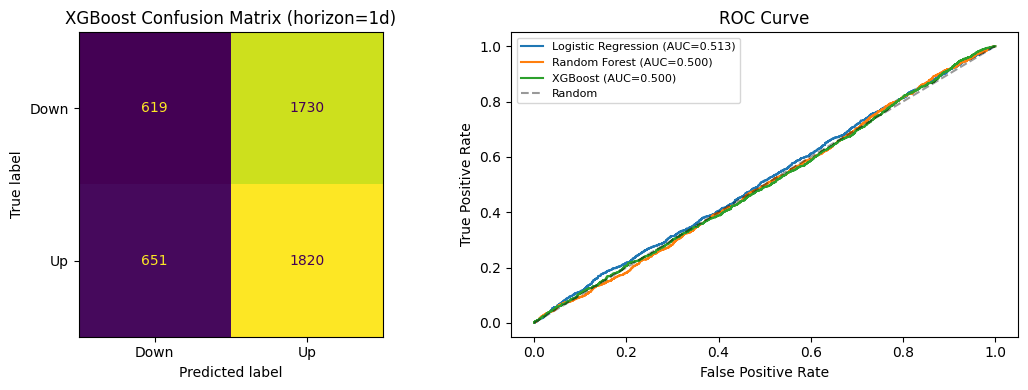

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_test, (proba_xgb > 0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"XGBoost Confusion Matrix (horizon={HORIZON}d)")

for name, proba in [("Logistic Regression", proba_lr), ("Random Forest", proba_rf), ("XGBoost", proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


## 11. Does the Prediction Horizon Matter?

Single-day price moves are dominated by noise (the core idea behind the **weak-form Efficient
Market Hypothesis**). As an exploratory comparison we repeat the *entire* leakage-free pipeline
(features -> embargoed split -> train with the hyperparameters CV picked for that horizon ->
evaluate) at 1, 5 and 10 trading days, and report the test ROC-AUC **with its bootstrap
confidence interval**.

This table is for *reporting only* — the horizon of our main model was already fixed in
section 8 using training data, so we are not choosing the best-looking row after the fact.


In [13]:
horizon_rows = []
horizon_models = {}
for h in HORIZONS:
    tr, te, c, _ = splits[h]
    prm = {k: v for k, v in best_by_h[h].items() if k != "cv_auc"}
    m = XGBClassifier(**prm, subsample=0.8, colsample_bytree=0.8,
                      eval_metric="logloss", random_state=RANDOM_STATE)
    m.fit(tr[FEATURES], tr["label_up"])
    horizon_models[h] = m
    pr = m.predict_proba(te[FEATURES])[:, 1]
    yt = te["label_up"].values
    lo, hi = block_bootstrap_auc(te["Date"].values, yt, pr)
    horizon_rows.append({
        "horizon_days": h,
        "cv_auc_train": round(best_by_h[h]["cv_auc"], 4),
        "test_accuracy": round(accuracy_score(yt, (pr > 0.5).astype(int)), 4),
        "majority_baseline": round(max(yt.mean(), 1 - yt.mean()), 4),
        "test_auc": round(roc_auc_score(yt, pr), 4),
        "auc_ci_low": round(lo, 3),
        "auc_ci_high": round(hi, 3),
    })

horizon_df = pd.DataFrame(horizon_rows)
horizon_df


,horizon_days,cv_auc_train,test_accuracy,majority_baseline,test_auc,auc_ci_low,auc_ci_high
0,1,0.5070,0.5060,0.5127,0.5005,0.485,0.516
1,5,0.4962,0.5242,0.5306,0.5076,0.485,0.534
2,10,0.4818,0.5230,0.5270,0.5225,0.492,0.556


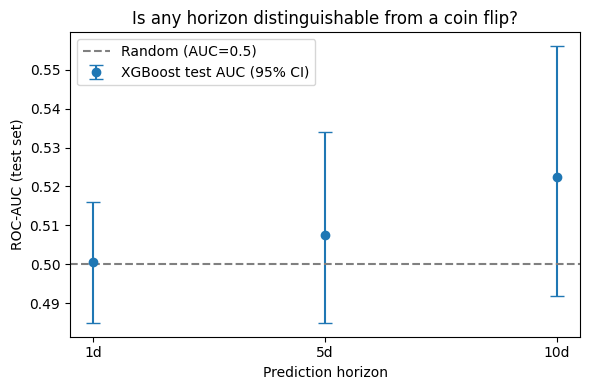

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
x = horizon_df["horizon_days"].astype(str) + "d"
err_low = horizon_df["test_auc"] - horizon_df["auc_ci_low"]
err_high = horizon_df["auc_ci_high"] - horizon_df["test_auc"]
ax.errorbar(x, horizon_df["test_auc"], yerr=[err_low, err_high], fmt="o", capsize=5, label="XGBoost test AUC (95% CI)")
ax.axhline(0.5, color="gray", linestyle="--", label="Random (AUC=0.5)")
ax.set_xlabel("Prediction horizon"); ax.set_ylabel("ROC-AUC (test set)")
ax.set_title("Is any horizon distinguishable from a coin flip?")
ax.legend(); plt.tight_layout(); plt.show()


## 12. Feature Importance & SHAP

Which indicators does the model use? We show XGBoost's built-in importance and SHAP values.
They describe the fitted model, but neither proves that a feature causes price changes or that
similar importance values imply noise. The held-out evaluation carries the main evidence.


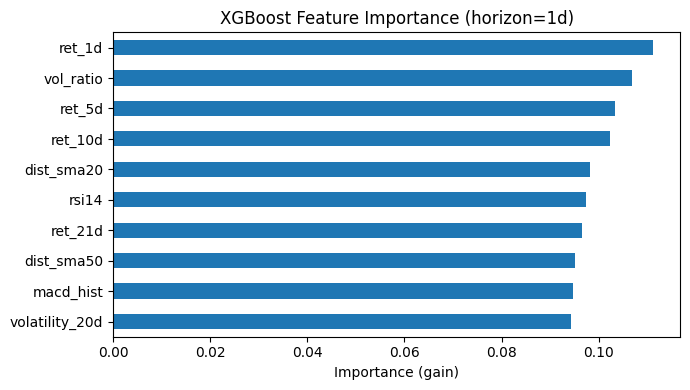

In [15]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax)
ax.set_title(f"XGBoost Feature Importance (horizon={HORIZON}d)")
ax.set_xlabel("Importance (gain)")
plt.tight_layout(); plt.show()


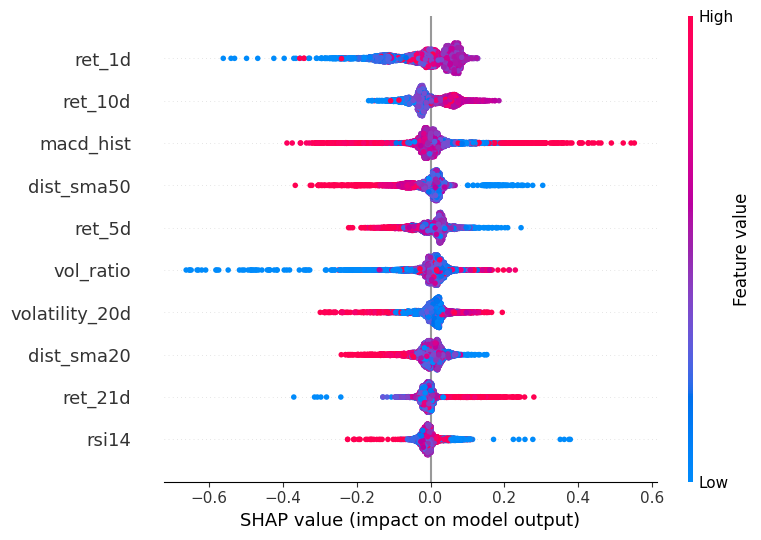

In [16]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=True)


## 13. Illustrative Strategy Backtest

> ⚠️ **Academic illustration only — not investment advice.** No transaction costs, slippage,
> taxes, or position sizing are modeled. Model probabilities are *statistical estimates*, not
> guarantees of future performance.

A toy strategy on the **one-day horizon** test period, regardless of which horizon won CV:
at each day's close, hold a ticker for the next trading day only if the one-day model's
probability of "up" is above a preset 0.55, otherwise stay in cash for that ticker.
Daily returns are averaged equally across the 20 tickers and compounded **once per day**, then
compared with simply holding all 20 tickers. Same-close execution is optimistic because the
signal uses that day's close; this is an illustration, not an executable trading simulation.


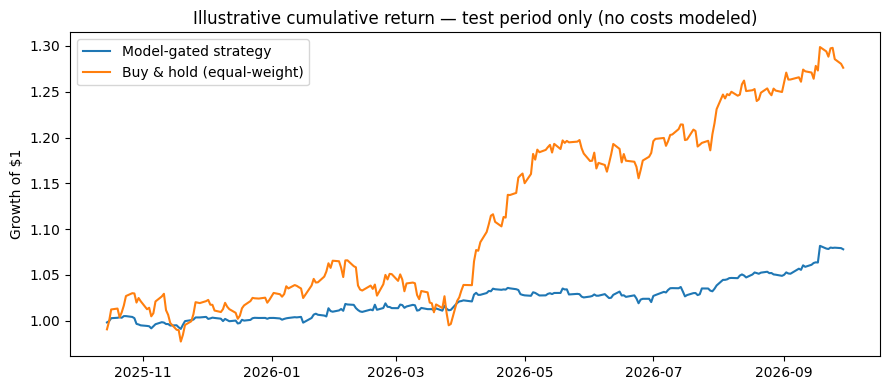

Strategy final growth   : 1.078x
Buy & hold final growth : 1.276x
Average share of tickers held by the strategy: 20.0%


In [17]:
bt = splits[1][1].copy()
bt["proba_up"] = horizon_models[1].predict_proba(bt[FEATURES])[:, 1]
# Next-day return per ticker (rows are sorted by date within each ticker)
bt["fwd_ret_1d"] = bt.groupby("Ticker")["Close"].transform(lambda s: s.shift(-1) / s - 1)
bt = bt.dropna(subset=["fwd_ret_1d"])

bt["position"] = (bt["proba_up"] > 0.55).astype(float)
bt["strategy_ret"] = bt["position"] * bt["fwd_ret_1d"]

strategy_cum = (1 + bt.groupby("Date")["strategy_ret"].mean()).cumprod()
holdall_cum = (1 + bt.groupby("Date")["fwd_ret_1d"].mean()).cumprod()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(strategy_cum.index, strategy_cum.values, label="Model-gated strategy")
ax.plot(holdall_cum.index, holdall_cum.values, label="Buy & hold (equal-weight)")
ax.set_title("Illustrative cumulative return — test period only (no costs modeled)")
ax.set_ylabel("Growth of $1"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Strategy final growth   : {strategy_cum.iloc[-1]:.3f}x")
print(f"Buy & hold final growth : {holdall_cum.iloc[-1]:.3f}x")
print(f"Average share of tickers held by the strategy: {bt['position'].mean():.1%}")


In [18]:
# Machine-readable audit snapshot for updating the presentation.
import json
presentation_results = {
    "data_start": str(full["Date"].min().date()),
    "data_end": str(full["Date"].max().date()),
    "rows": int(len(full)),
    "tickers": int(full["Ticker"].nunique()),
    "missing_ohlcv": int(full[["Open", "High", "Low", "Close", "Volume"]].isna().sum().sum()),
    "selected_horizon": int(HORIZON),
    "selected_params": best_params,
    "cv": json.loads(cv_df.to_json(orient="records")),
    "splits": [dict(r, train_end=str(r["train_end"]), test_start=str(r["test_start"]))
               for r in rows],
    "models": json.loads(results_df.drop(columns=["ci_low", "ci_high"]).to_json(orient="records")),
    "horizons": json.loads(horizon_df.to_json(orient="records")),
    "importance": {k: float(v) for k, v in importances.items()},
    "strategy_growth": float(strategy_cum.iloc[-1]),
    "hold_growth": float(holdall_cum.iloc[-1]),
    "share_held": float(bt["position"].mean()),
}
print("PRESENTATION_RESULTS_JSON=" + json.dumps(presentation_results, ensure_ascii=False, default=str))


PRESENTATION_RESULTS_JSON={"data_start": "2021-10-04", "data_end": "2026-10-01", "rows": 25080, "tickers": 20, "missing_ohlcv": 0, "selected_horizon": 1, "selected_params": {"max_depth": 3, "learning_rate": 0.05, "n_estimators": 200}, "cv": [{"horizon": 1, "max_depth": 3, "learning_rate": 0.05, "n_estimators": 200, "cv_auc": 0.507}, {"horizon": 1, "max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "cv_auc": 0.506}, {"horizon": 1, "max_depth": 3, "learning_rate": 0.1, "n_estimators": 150, "cv_auc": 0.5065}, {"horizon": 5, "max_depth": 3, "learning_rate": 0.05, "n_estimators": 200, "cv_auc": 0.4952}, {"horizon": 5, "max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "cv_auc": 0.4962}, {"horizon": 5, "max_depth": 3, "learning_rate": 0.1, "n_estimators": 150, "cv_auc": 0.4959}, {"horizon": 10, "max_depth": 3, "learning_rate": 0.05, "n_estimators": 200, "cv_auc": 0.4766}, {"horizon": 10, "max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "cv_auc": 0.4818}, {"horizo

**Reading this result:** the strategy only holds a stock when the model is confident, so it is
invested a minority of the time, while the test window contains a broad market uptrend. Missing
those "up" days in cash costs more than a statistically undetectable edge can recover.
**A small change in AUC is not automatically a profitable trading strategy** — timing
decisions carry an opportunity cost that accuracy/AUC numbers alone do not show.


## 14. Limitations

- **No statistically detectable edge in this experiment.** The 95% ROC-AUC confidence intervals
  in sections 10-11 include 0.5. We therefore cannot establish that these models rank up days
  above down days better than random ranking on this test window. This does not prove that the
  true AUC is exactly 0.5, nor does it establish market efficiency in general.
- **Small effective sample.** The test set has ~4,800 rows, but the 20 stocks move together on
  any given day and the labels of neighbouring days overlap, so the *effective* number of
  independent observations is much smaller — which is why we use a block bootstrap.
- **Multiple comparisons.** We looked at 3 horizons and 3 hyperparameter settings; any one result
  that looks slightly good would need to survive that multiplicity before being trusted.
- **No fundamental or macro data.** Earnings, interest rates, news events, and broad market
  regime shifts are not in the feature set.
- **Survivorship bias.** Our 20 tickers are large, currently-listed companies; delisted/failed
  companies are excluded, which can inflate apparent predictability.
- **Optimistic backtest** in Section 13: no transaction costs, slippage, taxes or realistic
  execution delay. It is not evidence of an investable strategy.
- **Public data, not our own.** All data come from Yahoo Finance via `yfinance`; we did not
  collect or label a new dataset.
- **Live sentiment (Stockscope's news + VADER scraper) is not included here** — Yahoo News only
  exposes *current* headlines, not a historical archive aligned to each past trading day, so it
  cannot be backtested with this free data source.

## 15. Conclusion

- We built a pipeline with backward-looking features, a forward-looking label, date-based
  training/validation/test splits, and a purge based on each row's actual target date. Horizon
  and hyperparameters were chosen using training data only.
- On this fixed snapshot, the selected one-day XGBoost model has test ROC-AUC about **0.500**
  (95% block-bootstrap interval about **0.485-0.516**). All three tested horizon intervals
  include 0.5, so this experiment does not establish predictive ranking above random.
- The illustrative one-day strategy grew $1 to about **$1.078**, versus **$1.276** for the
  equal-weight buy-and-hold comparison, before costs and realistic execution.
- **Main insight:** the experiment did not find a reliable signal in these indicators for this
  sample and period. It does not prove the absence of a signal in every market or setting.

## 16. Future Work

- Add information technical indicators don't contain (fundamentals, earnings surprises, macro
  data, and — with a historical news source — sentiment) and re-run the same pipeline.
- Try cross-sectional ranking (which stocks do better than others) instead of up/down per stock.
- Our dashboard (Stockscope) already computes these indicators live for any ticker; the trained
  model could be shown there as an *experimental, low-confidence* estimate — clearly labeled as
  a statistical estimate, not financial advice.
